In [124]:
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd
df = pd.read_csv(r"D:\Ai engineering course\datasets\AER_credit_card_data.csv")

In [125]:
df

,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,yes,0,37.66667,4.5200,0.033270,124.983300,yes,no,3,54,1,12
1,yes,0,33.25000,2.4200,0.005217,9.854167,no,no,3,34,1,13
2,yes,0,33.66667,4.5000,0.004156,15.000000,yes,no,4,58,1,5
3,yes,0,30.50000,2.5400,0.065214,137.869200,no,no,0,25,1,7
4,yes,0,32.16667,9.7867,0.067051,546.503300,yes,no,2,64,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1314,yes,0,33.58333,4.5660,0.002146,7.333333,yes,no,0,94,1,19
1315,no,5,23.91667,3.1920,0.000376,0.000000,no,no,3,12,1,5
1316,yes,0,40.58333,4.6000,0.026513,101.298300,yes,no,2,1,1,2
1317,yes,0,32.83333,3.7000,0.008999,26.996670,no,yes,0,60,1,7


In [126]:
df.describe()

,reports,age,income,share,expenditure,dependents,months,majorcards,active
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,0.456406,33.213103,3.365376,0.068732,185.057071,0.993935,55.267627,0.817286,6.996967
std,1.345267,10.142783,1.693902,0.094656,272.218917,1.247745,66.271746,0.386579,6.305812
min,0.000000,0.166667,0.210000,0.000109,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,25.416670,2.243750,0.002316,4.583333,0.000000,12.000000,1.000000,2.000000
50%,0.000000,31.250000,2.900000,0.038827,101.298300,1.000000,30.000000,1.000000,6.000000
75%,0.000000,39.416670,4.000000,0.093617,249.035800,2.000000,72.000000,1.000000,11.000000
max,14.000000,83.500000,13.500000,0.906320,3099.505000,6.000000,540.000000,1.000000,46.000000


In [147]:
df['num_owner'] = df['owner'].replace({'yes': 1, 'no': 0})
df


,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active,num_owner
0,yes,0,37.66667,4.5200,0.033270,124.983300,yes,no,3,54,1,12,1
1,yes,0,33.25000,2.4200,0.005217,9.854167,no,no,3,34,1,13,0
2,yes,0,33.66667,4.5000,0.004156,15.000000,yes,no,4,58,1,5,1
3,yes,0,30.50000,2.5400,0.065214,137.869200,no,no,0,25,1,7,0
4,yes,0,32.16667,9.7867,0.067051,546.503300,yes,no,2,64,1,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1314,yes,0,33.58333,4.5660,0.002146,7.333333,yes,no,0,94,1,19,1
1315,no,5,23.91667,3.1920,0.000376,0.000000,no,no,3,12,1,5,0
1316,yes,0,40.58333,4.6000,0.026513,101.298300,yes,no,2,1,1,2,1
1317,yes,0,32.83333,3.7000,0.008999,26.996670,no,yes,0,60,1,7,0


In [127]:
import matplotlib.pyplot as plt

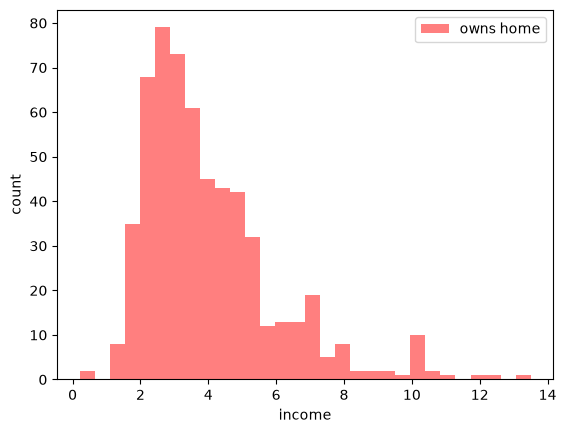

In [144]:
no_home  = df[df["owner"] == "no"]
yes_home = df[df["owner"] == "yes"]

plt.hist(yes_home["income"], bins=30, alpha=0.5,color = "red", label="owns home")

plt.xlabel("income")
plt.ylabel("count")
plt.legend()
plt.show()

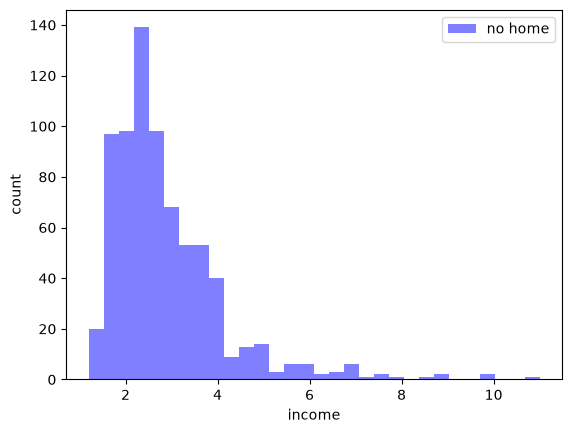

In [130]:
plt.hist(no_home["income"],  bins=30, alpha=0.5,color ="blue", label="no home")

plt.xlabel("income")
plt.ylabel("count")
plt.legend()
plt.show()

In [148]:
X = df[['income', 'num_owner', 'reports']]
y = df['card'] 


In [154]:
pre = ColumnTransformer([
   
     ("val", StandardScaler(), ["income","reports"]), ])


models = {
    "Logistic": Pipeline([("prep", pre), ("clf", LogisticRegression(max_iter=1000))]),
    "MLP": Pipeline([("prep", pre), ("clf", MLPClassifier(hidden_layer_sizes=(64), max_iter=2000, random_state=42))]),
    "Forest": Pipeline([("prep", pre), ("clf", RandomForestClassifier(n_estimators=500, random_state=42))]),
}




for name, m in models.items():
    s = cross_val_score(m, X, y, cv=5, scoring='accuracy')
    print(f"{name} - Accuracy: {round(s.mean(), 3)} | Std: {round(s.std(), 3)}")
    

Logistic - Accuracy: 0.843 | Std: 0.012
MLP - Accuracy: 0.842 | Std: 0.013
Forest - Accuracy: 0.808 | Std: 0.022


In [155]:

best_model = models["Logistic"]

best_model.fit(X, y)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['no','yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](3,)","['income','num_owner','reports']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,3
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('val', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers

In [183]:

def check_loan_eligibility(income, owner, reports):
    new_applicant = pd.DataFrame([{
        'income': float(income),
        'owner': str(owner),     
        'reports': float(reports)
    }])
    

    approval_chance = best_model.predict_proba(new_applicant)[0][1]
    

    if approval_chance > 0.80 :
        return f"Approved! (Approval Probability: {approval_chance:.1%})"
    else:
        return f"Rejected. (Approval Probability: {approval_chance:.1%})"


In [184]:

# def check_loan_eligibility(income, owner, reports):
#     new_applicant = pd.DataFrame([{
#         'income': float(income),
#         'owner': str(owner),     
#         'reports': float(reports)
#     }])
    
#     # 1. Look directly at the approval probability (Index 1)
#     approval_chance = best_model.predict_proba(new_applicant)[0][1]
    
#     # 2. Bypassing predict(): If approval chance is > 50%, they are approved!
#     if approval_chance >= 0.5:
#         return f"Approved! (Approval Probability: {approval_chance:.1%})"
#     else:
#         return f"Rejected. (Approval Probability: {approval_chance:.1%})"


In [185]:
# Example 1: High income, homeowner, 0 bad reports
print("Applicant 1:", check_loan_eligibility(income=8.5, owner=1, reports=0))

# Example 2: Low income, renter, 3 bad reports
print("Applicant 2:", check_loan_eligibility(income=1.5, owner=0, reports=3))


Applicant 1: Approved! (Approval Probability: 96.0%)
Applicant 2: Rejected. (Approval Probability: 7.3%)
